In [ ]:
import json
import os
import sys
from os import path
sys.path.insert(0, "/home/thomasb")
import numpy as np
from albatros_analysis.src.utils import orbcomm_utils as outils
from albatros_analysis.src.utils import baseband_utils as butils
import importlib
import pulsedata_file_helper as ph
import matplotlib.pyplot as plt

In [3]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)
    
def extract_snr_dict(data):
    snr_dict = {}
    for timestamp, antenna_data in data.items():
        pulses = antenna_data.get("Antenna 6", {}).get("pulse_data", [])
        for pulse in pulses:
            start = pulse["start"]
            end = pulse["end"]
            sats_present = pulse.get("sats_present", {})

            for satID, detections in sats_present.items():
                max_snr = max(det[2] for det in detections)
                key = (timestamp, start, end, satID)
                snr_dict[key] = max_snr
    return snr_dict

In [4]:
def extract_snr_dict2(data, ant_name):
    snr_dict = {}
    for start_timestamp, antenna_data in data.items():
        pulses = antenna_data.get(ant_name, {}).get("pulse_data", [])
        for pulse in pulses:
            start = pulse["start"]
            end = pulse["end"]
            sats_present = pulse.get("sats_present", {})

            for satID, detections in sats_present.items():
                max_snr = max(det[2] for det in detections)
                key = (start, end)
                snr_dict[key] = (max_snr, satID)
    return start_timestamp, snr_dict

In [55]:
dir = '/scratch/thomasb'

config_uncorr = os.path.join(dir, "pulsedata_1753132820_len_67200_1760024247.5361912.json")
config_corr = os.path.join(dir, "pulsedata_1753132820_len_67200_1760452124.3504817.json")
config_long = os.path.join(dir, "pulsedata_1753200150_len_86260_1760835173.json")

In [74]:
importlib.reload(ph)

<module 'pulsedata_file_helper' from '/home/thomasb/albatros_analysis/scripts/orbcomm/pulsedata_file_helper.py'>

1753200150 input
1753200150 from file


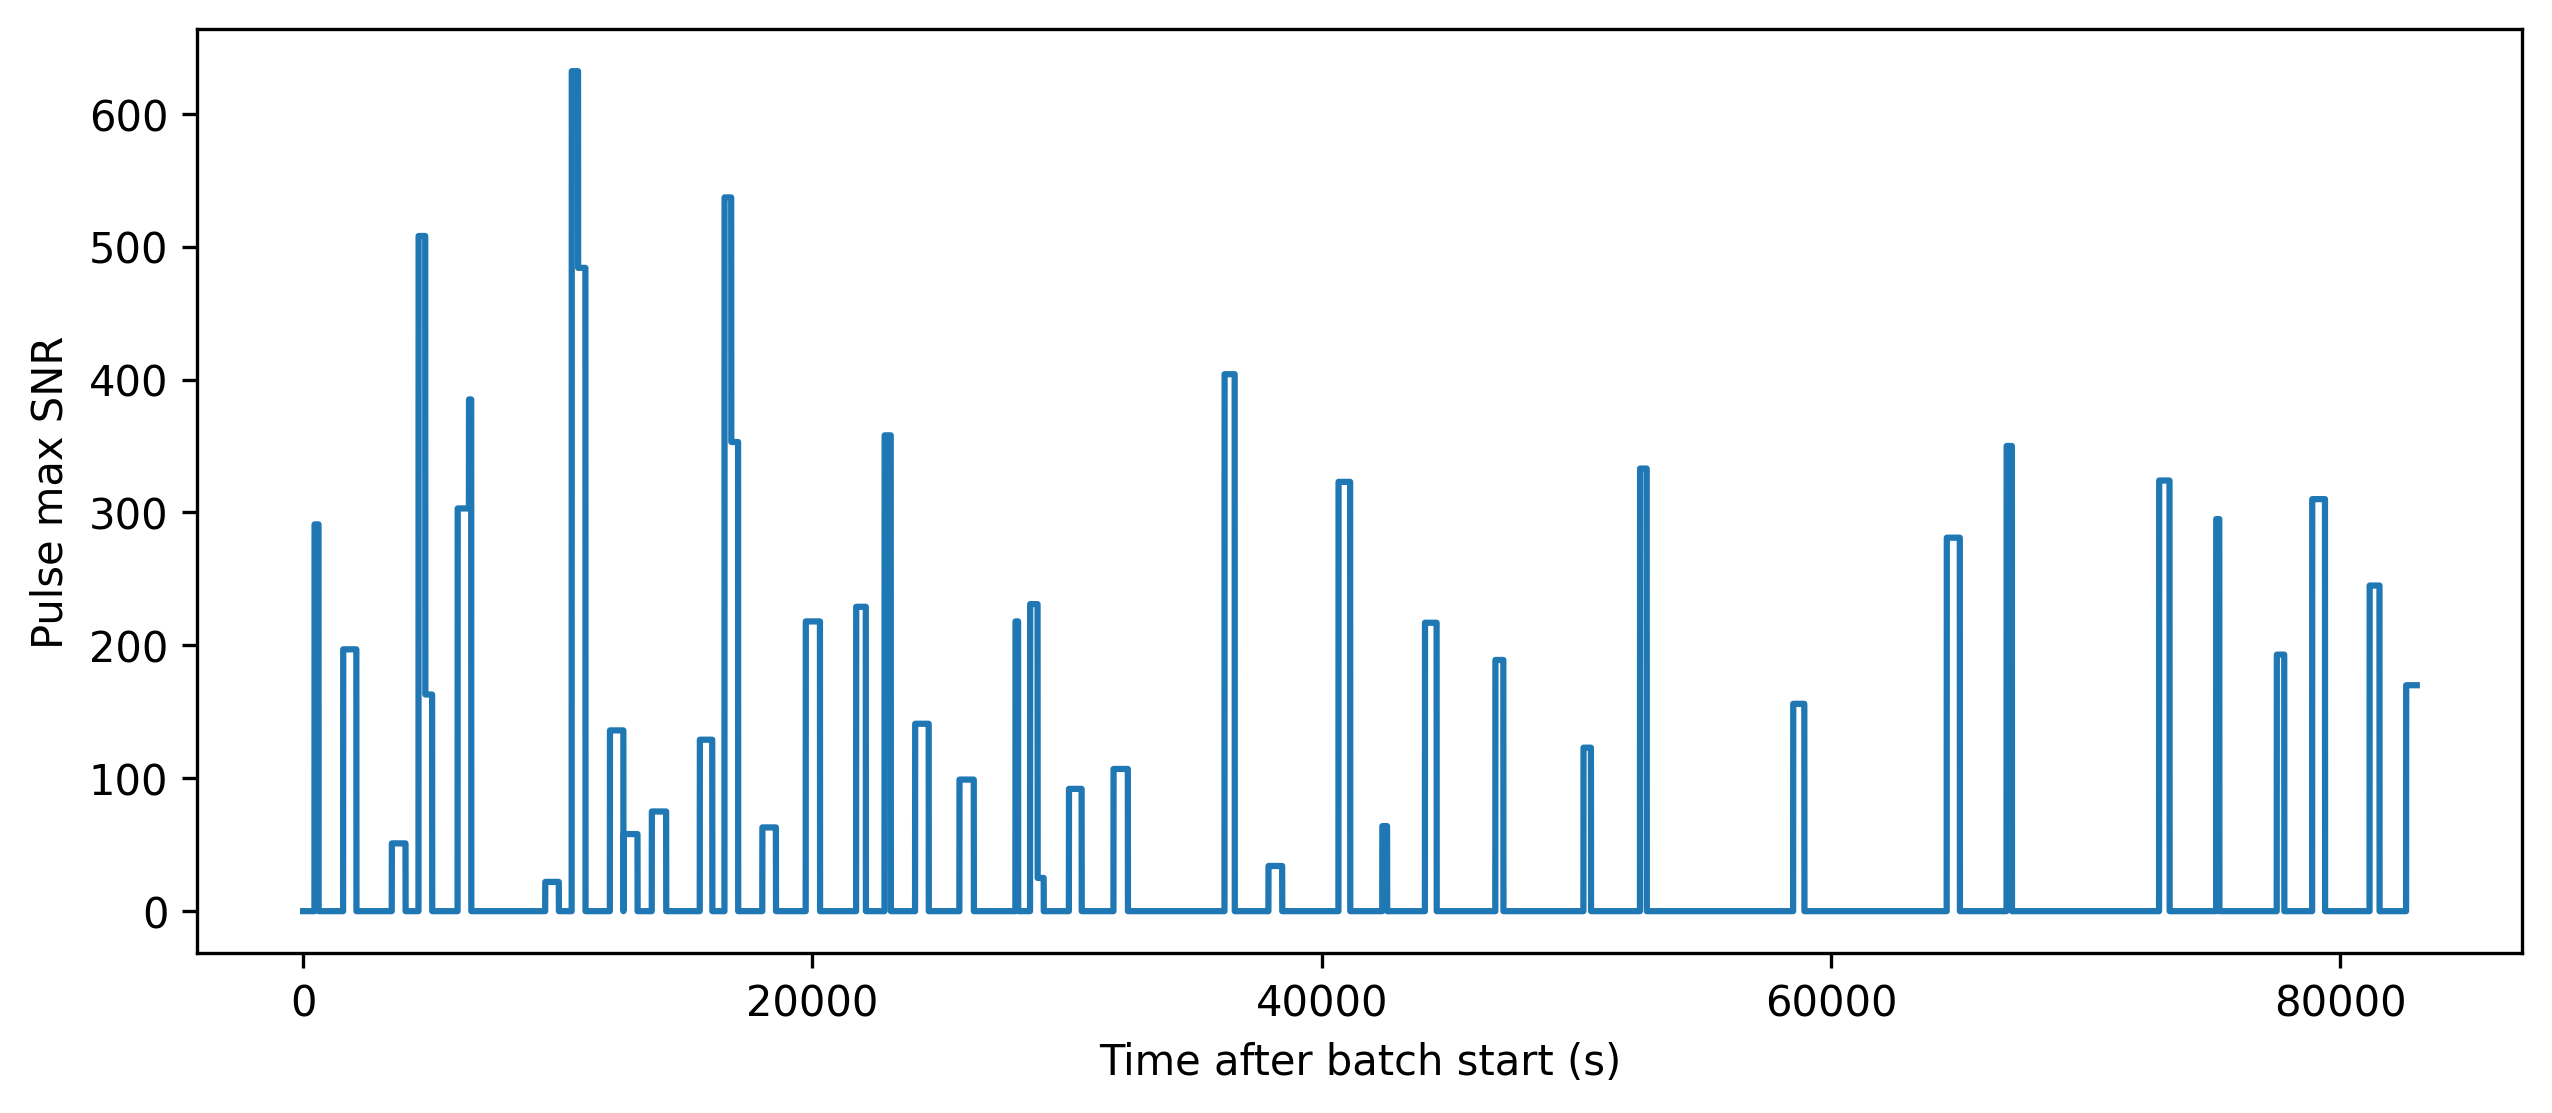

In [75]:
snrs, fig = ph.get_snr_vs_time(config_long, 1753200150, 1753200150+83000, 'Antenna 2', plot=True)

In [26]:
def unix_to_lst_with_fix(start_unix, end_unix, coords):
    """ 
    Assume that interval can be no longer than 24 hrs, so that we can unwrap safely by 360
    """

    start_lst = ph.unix_to_lst(start_unix, coords)
    end_lst = ph.unix_to_lst(end_unix, coords)

    if start_lst > end_lst:
        return (start_lst, end_lst + 360)
    else:
        return (start_lst, end_lst)

In [132]:
coords = [79.41717895, -90.76721818, 188.095]
path1 = config_corr
path2 = config_long

start1 = 1753132820
end1 = 1753132820 + 70000

start2 = 1753200150
end2 = 1753200150 + 83000

ant_name = 'Antenna 2'
plot = True

1753132820 input
1753132820 from file
1753200150 input
1753200150 from file
(169.20739175867078, 461.6726183523525)
(90.51715899442962, 437.29735594413023)
True
88885
83000


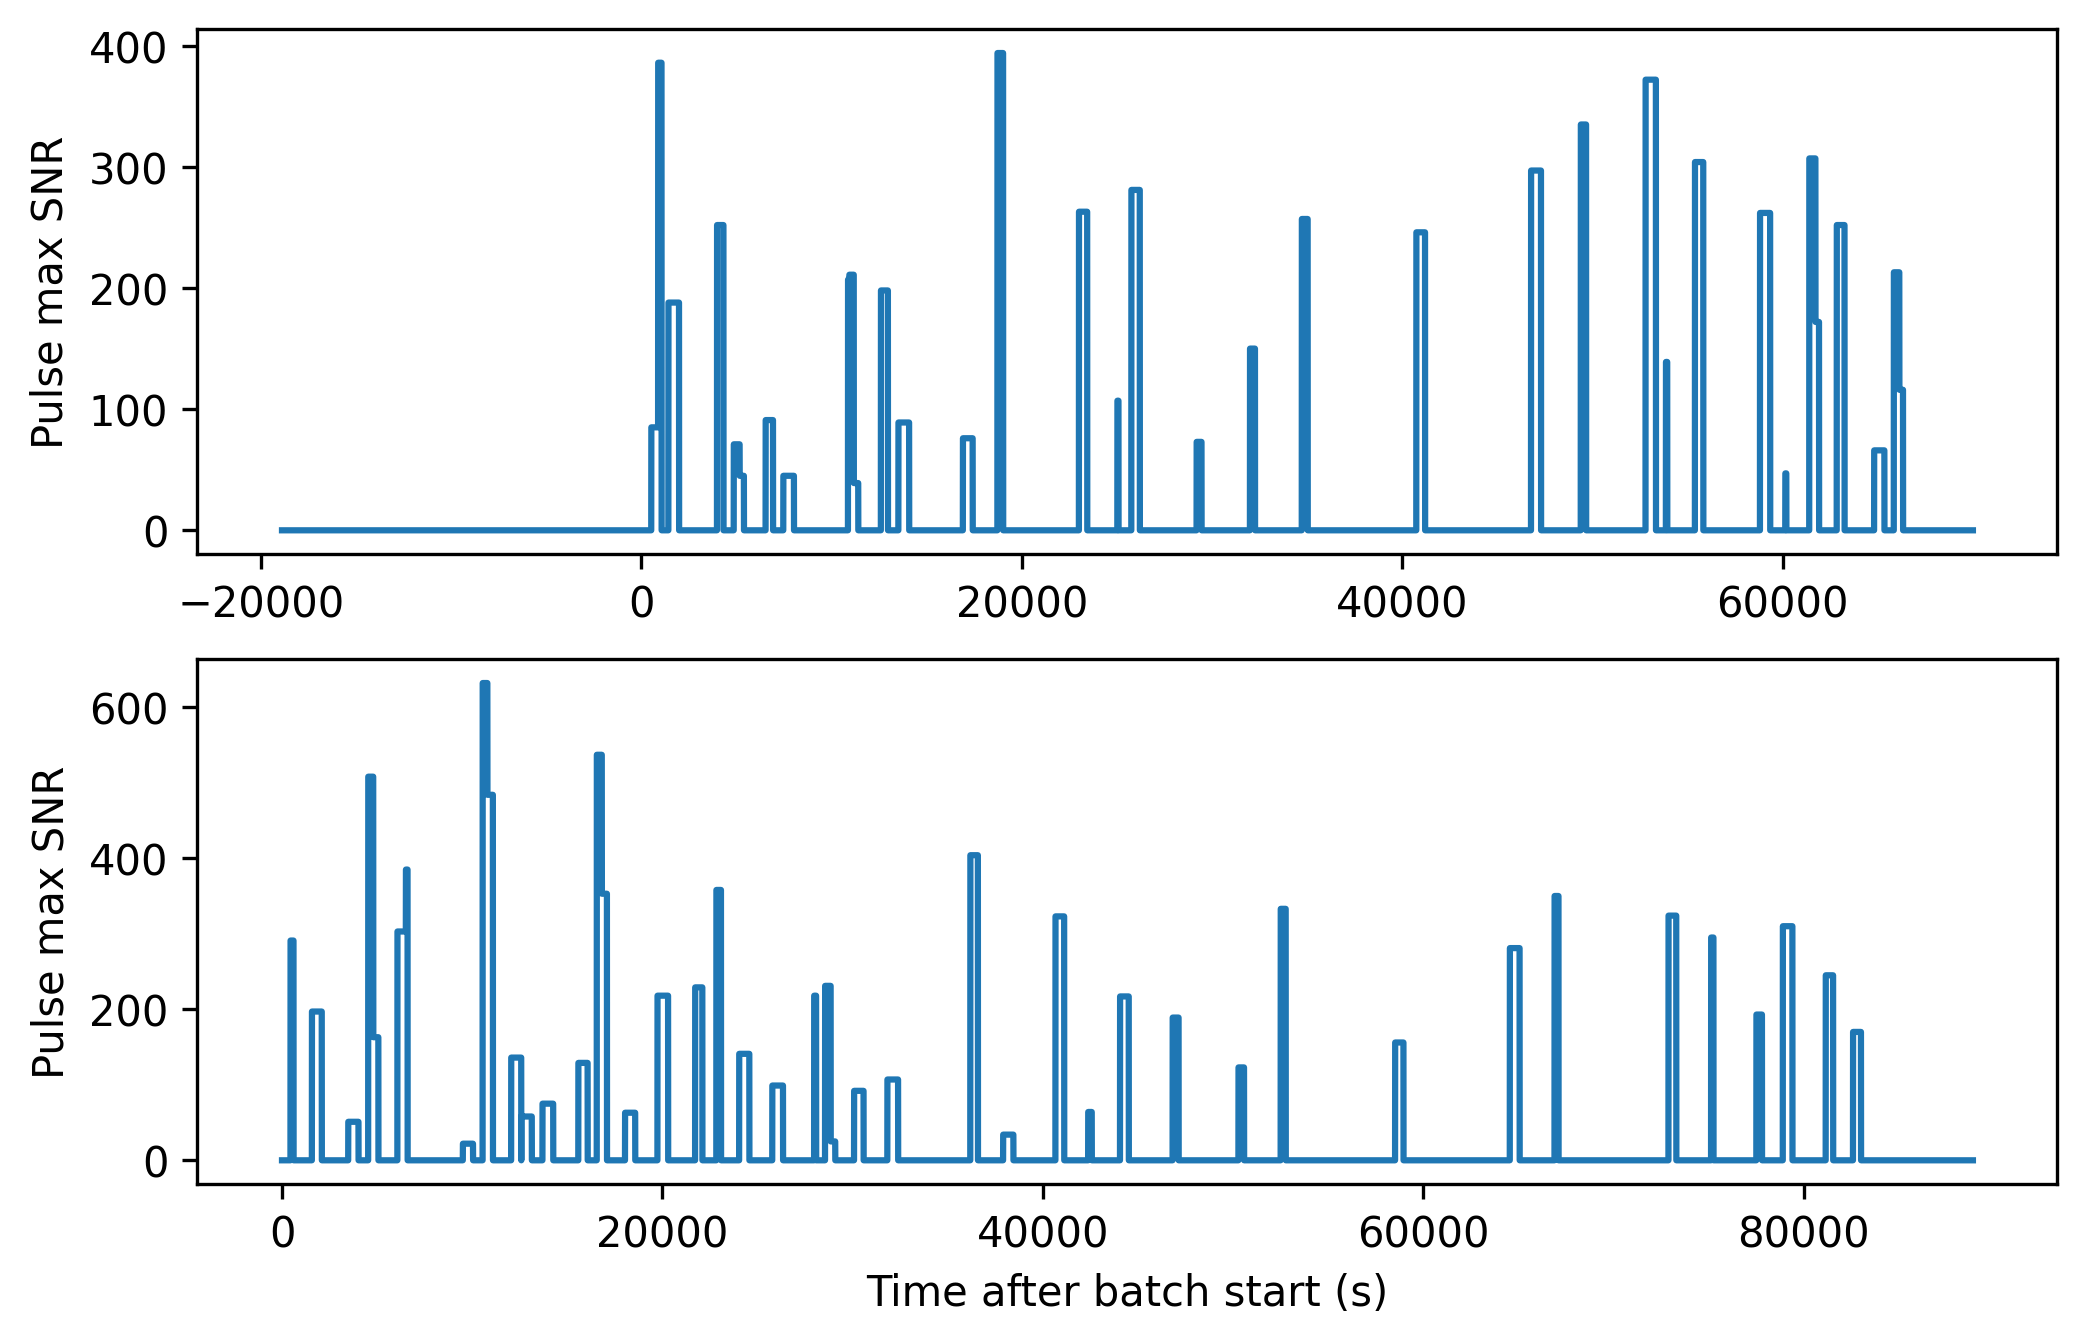

In [133]:
#def get_snr_vs_time_2plot(path1, start1, end1, path2, start2, end2, ant_name, plot=True):

#get snrs
snrs1 = ph.get_snr_vs_time(path1, start1, end1, ant_name, plot=False)
snrs2 = ph.get_snr_vs_time(path2, start2, end2, ant_name, plot=False)
times1 = np.arange(end1-start1)
times2 = np.arange(end2-start2)

#get fixed (unwrapped) lst intervals
start1_lst, end1_lst = unix_to_lst_with_fix(start1, end1, coords)
start2_lst, end2_lst = unix_to_lst_with_fix(start2, end2, coords)

print((float(start1_lst), float(end1_lst)))
print((float(start2_lst), float(end2_lst)))

#check if there's overlap
if end2_lst > start1_lst:
    overlap = True
elif end1_lst > start2_lst:
    overlap = True
else:
    overlap = False

#overlap means we actually want to do this plot, otherwise no point
print(overlap)

#check which one is first (modulo 360 of course)
#convention is that 1 starts before 2
flip = False
if start2_lst < start1_lst:
    flip = True

if flip:
    #2 comes first so have to pad 1
    difference_secs = int((start1_lst - start2_lst)*240)
    snrs1 = np.pad(snrs1, (difference_secs, 0), mode='constant', constant_values=0)
    neg_seq = np.arange(-difference_secs, 0)  
    times1 = np.concatenate([neg_seq, times1])
else:
    #1 comes first so have to pad 2
    difference_secs = int((start2_lst - start1_lst)*240)
    snrs2 = np.pad(snrs2, (difference_secs, 0), mode='constant', constant_values=0)
    neg_seq = np.arange(-difference_secs, 0)  
    times2 = np.concatenate([neg_seq, times2])


#now check which ones ends first
end1, end2 = len(times1), len(times2)
print(end1)
print(end2)

if end1 < end2:
    snrs1 = np.pad(snrs1, (0, end2-end1), mode='constant', constant_values=0)
    pos_seq = np.arange(end1,end2)
    times1 = np.concatenate([times1, pos_seq])
else:
    snrs2 = np.pad(snrs2, (0, end1-end2), mode='constant', constant_values=0)
    pos_seq = np.arange(end2, end1)
    times2 = np.concatenate([times2, pos_seq])

if plot:          
    fig, ax = plt.subplots(2, 1, dpi=300)
    fig.set_size_inches(8,5)
    ax[0].plot(times1, snrs1)
    ax[0].set_ylabel('Pulse max SNR')

    ax[1].plot(times2, snrs2)
    ax[1].set_xlabel('Time after batch start (s)')
    ax[1].set_ylabel('Pulse max SNR')

In [18]:
path1 = '/scratch/thomasb/satdet_data_1753132820_1M_len_7180_1769193967.json'
start1 = 1753132820
end1 = 1753132820 + 8000

path2 = '/scratch/thomasb/satdet_data_1753200150_3M_len_6000_1769192936.json'
start2 = 1753200150
end2 = 1753200150 + 6000


In [19]:
def snr_times_single(json_path, batch_start_unix, batch_end_unix, antname, dt=1):
    data_all = load_json(json_path)
    data = data_all[f'{batch_start_ts}'][f'{antname}']


    # make time grid
    t_start = 0
    t_end = batch_end_unix - batch_start_unix

    time = np.arange(t_start, t_end + 1, dt)
    snr  = np.zeros_like(time, dtype=float)

    # extract pulse times (floats since chunked)
    for block in data:
        t0, t1 = block["times"]
        t0 -= batch_start_unix
        t1 -= batch_start_unix
        snr_vals = [x[0] for x in block["SNR, Chan"]] #beware name might change here
        n = len(snr_vals)

        # get chunk boundaries (since SNR will change across them)
        boundaries = np.linspace(t0, t1, n + 1)

        for i, val in enumerate(snr_vals):
            # seconds covered by this SNR value
            mask = (time >= boundaries[i]) & (time < boundaries[i + 1])
            snr[mask] = val

    plt.figure(figsize=(10, 4))
    plt.step(time, snr, where="post")
    plt.xlabel(f"Time after Batch Start ({int(dt)} s)")
    plt.ylabel("SNR")
    plt.title(f"Antenna 1 - {antname}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [23]:
snr_times_single(path1, batch_start_ts, batch_end_ts, 'Antenna 2')

NameError: name 'batch_start_ts' is not defined

In [21]:
def snr_times_many(json_paths, batch_starts, batch_ends, antname, dt=1, coords = [79.41717895, -90.76721818, 188.095]):
    #using coords of MARS 1 as a reference for LST
    assert len(json_paths) == len(batch_starts)
    assert len(json_paths) == len(batch_ends)
    nbatches = len(json_paths)

    secs, lsts, snrs = [], [], []
    for i in range(nbatches):
        data = load_json(json_paths[i])[f'{batch_starts[i]}'][f'{antname}']
        secs.append(np.arange(0, batch_ends[i]-batch_starts[i] + 1, dt))
        lsts.append(unix_to_lst_with_fix(batch_starts[i], batch_ends[i], coords))
        snr  = np.zeros_like(secs[i], dtype=float)

        # extract pulse times (floats since chunked)
        for pulse in data:
            t0, t1 = pulse["times"]
            t0 -= batch_starts[i]
            t1 -= batch_starts[i]
            snr_vals = [x[0] for x in pulse["SNR, Chan, Sat"]]
            n = len(snr_vals)

            # get chunk boundaries (since SNR will change across them)
            boundaries = np.linspace(t0, t1, n + 1)

            for j, val in enumerate(snr_vals):
                # seconds covered by this SNR value
                mask = (secs[i] >= boundaries[j]) & (secs[i] < boundaries[j + 1])
                snr[mask] = val
        snrs.append(snr)

    start_lsts = [float(lst[0]) for lst in lsts]
    print(start_lsts)
    lst_min = min(start_lsts)
    print(lst_min)

    lst_to_sec = 240
    aligned_secs = []
    aligned_snrs = []

    for sec, snr, start_lst in zip(secs, snrs, start_lsts):
        shift_sec = int((start_lst - lst_min) * lst_to_sec)

        if shift_sec > 0:
            # pad at the beginning
            snr = np.pad(snr, (shift_sec, 0), constant_values=0)
            sec = np.concatenate([np.arange(-shift_sec, 0), sec])

        aligned_snrs.append(snr)
        aligned_secs.append(sec)

    max_len = max(len(s) for s in aligned_snrs)

    for i in range(len(aligned_snrs)):
        pad = max_len - len(aligned_snrs[i])
        if pad > 0:
            aligned_snrs[i] = np.pad(
                aligned_snrs[i], (0, pad), constant_values=0
            )
            aligned_secs[i] = np.concatenate(
                [aligned_secs[i], np.arange(len(aligned_secs[i]), max_len)]
            )

    aligned_snrs = aligned_snrs
    fig, ax = plt.subplots(nbatches, 1, figsize=(8, 3 * nbatches), dpi = 300)
    if nbatches == 1:
        ax = [ax]
    fig.suptitle(f"Antenna 1 - {antname} (time axis shifted to align batches by LST)")
    for i in range(nbatches):
        ax[i].step(aligned_secs[i], aligned_snrs[i], where="post")
        ax[i].set_ylabel("SNR")
        ax[i].grid(True)
    
    ax[nbatches-1].set_xlabel(f"Time after Batch Start ({int(dt)} s)")
    plt.tight_layout()
    
    return secs, snrs, fig 

In [22]:
snr_times_many([path1, path2], [start1, start2], [end1, end2], 'Antenna 2')

NameError: name 'unix_to_lst_with_fix' is not defined

mars1
mars2
mars3
mars4
mars5
mars6
mars7
mars8
raw file ant mars1 ['/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113700.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113753.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113807.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113861.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113915.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753113969.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114022.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114075.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114128.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114183.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114237.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114289.raw', '/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753114345.raw', '/scratch/mohanagr/summer_2025/base

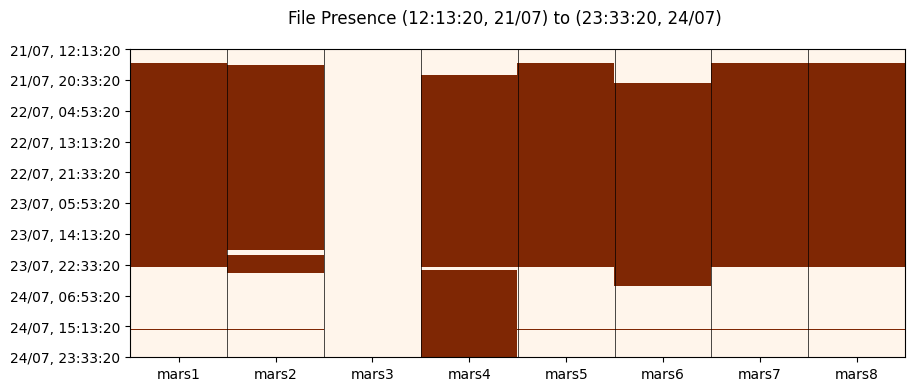

In [8]:
ant_path_list = ['/scratch/mohanagr/summer_2025/baseband/mars1',
'/scratch/mohanagr/summer_2025/baseband/mars2',
'/scratch/mohanagr/summer_2025/baseband/mars3',
'/scratch/mohanagr/summer_2025/baseband/mars4',
'/scratch/mohanagr/summer_2025/baseband/mars5',
'/scratch/mohanagr/summer_2025/baseband/mars6',
'/scratch/mohanagr/summer_2025/baseband/mars7',
'/scratch/mohanagr/summer_2025/baseband/mars8']

arr, fig = butils.get_present_files(1753100000, 1753400000, ant_path_list)

In [15]:
runs = butils.get_simul_files(arr, 1753100000, 10, [0, 1, 3, 4, 5, 6, 7])
print(runs)

[[1753132820, 1753200010], [1753200150, 1753286400], [1753286530, 1753296030], [1753300680, 1753311920], [1753372970, 1753373350]]


In [7]:
def compare_snrs(snr_dict1, snr_dict2):
    all_keys = set(snr_dict1.keys()) | set(snr_dict2.keys())
    comparison = []

    for key in sorted(all_keys):
        snr1 = snr_dict1.get(key, None)
        snr2 = snr_dict2.get(key, None)

        comparison.append({
            "timestamp": key[0],
            "pulse_start": key[1],
            "pulse_end": key[2],
            "satID": key[3],
            "SNR_file1": snr1,
            "SNR_file2": snr2,
            "diff": snr1 - snr2 if snr1 is not None and snr2 is not None else None
        })
    return comparison

def get_diff_list(comparison, skip_missing = True):
    diff_list = []
    for entry in comparison:
        diff = entry['diff']
        if skip_missing and diff is None:
            continue
        diff_list.append(diff)
    return diff_list

def print_comparison_table(comparison):
    print(f" {'Start':>6} {'End':>6} {'SatID':>8} {'SNR1':>10} {'SNR2':>10} {'ΔSNR':>10}")
    print("-"*64)
    for item in comparison:
        print(f"{item['pulse_start']:>6} {item['pulse_end']:>6} {item['satID']:>8} "
              f"{item['SNR_file1'] if item['SNR_file1'] is not None else '—':>10} "
              f"{item['SNR_file2'] if item['SNR_file2'] is not None else '—':>10} "
              f"{item['diff'] if item['diff'] is not None else '—':>10}")
        
def print_no_sat_times(data):
    time_set = set()
    for timestamp, all_data in data.items():
        for antname, antenna_data in all_data.items():
            for pulse in antenna_data['pulse_data']:
                start = pulse["start"]
                end = pulse["end"]
                time_set.add((start, end))
        
    times = list(time_set)
    sorted_times = sorted(times, key=lambda x : x[0])

    gaps = []
    lengths = []
    for i in range(1, len(sorted_times)):
        start = sorted_times[i-1][1]
        end = sorted_times[i][0]
        gaps.append((start, end))
        lengths.append(end-start)

    #print('all sat gaps:')
    #for gap in gaps:
    #    print(gap)
    print('mean seconds with no sat risen', int(np.mean(lengths)))
    print('in minutes:', int(np.mean(lengths)/60))
    print('longest in minutes:', int(max(lengths)/60))

In [8]:
def get_shared_pulses(
        config_data,
        pulse_data,
        satlist = [28654,25338,33591,57166,59051,44387],
        T_SCAN = 5,
        alt_cutoff = 15):
    
    ''' 
    Gets the pulses that are shared in all baselines, that all see the same satellite.


    Parameters
    ----------


    Returns
    -------

    
    
    '''

    ref_coords = config_data["antennas"]["ALB1"]["coordinates"]
    print(ref_coords)
    global_start_t = config_data["correlation"]["start_timestamp"]
    global_end_t = config_data["correlation"]["end_timestamp"]
    array_time =  global_end_t - global_start_t
    tle_path = outils.get_tle_file(global_start_t, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

    satmap = {} 
    assert min(satlist) > len(satlist)
    for i, sat_ID in enumerate(satlist):
        satmap[i] = sat_ID
        satmap[sat_ID] = i
    print(satmap)

    #RISEN SATS
    nrows = int((array_time)/T_SCAN)
    arr = np.zeros((nrows, len(satlist)), dtype="int64")
    rsats = outils.get_risen_sats(tle_path, 
                                  ref_coords, 
                                  global_start_t, 
                                  dt=T_SCAN, 
                                  niter=nrows, 
                                  good=satlist, 
                                  altitude_cutoff=alt_cutoff)
    for i, row in enumerate(rsats):
        for sat_ID, satele, sataz in row:
            arr[i,satmap[sat_ID]] = 1

    #PASSES
    p_5s = outils.get_simul_pulses(arr)
    passes = []
    for p in p_5s:
        passes.append([[p[0][0]*5, p[0][1]*5], p[1]])
    npasses = len(passes)
    for passs in passes:
        print(passs)
    print("PASSES DETECTED:",'\n', passes, '\n')
    print("Number of Passes:", npasses, '\n')

    bline_data_all = pulse_data[f'{global_start_t}'] #good check to see if I have the right file

    shared_passes = []
    for satpass in passes:
        pass_start = satpass[0][0]
        print('STARTING PASS', pass_start)
        temp_dict = {}
        temp_dict[f'{pass_start}'] = {}
        sat_set = set() #could make this all possible satellites, not just in rsats?

        for sat_idx in satpass[1]:
            sat_set.add(satmap[sat_idx])

        for antenna, bline_data in bline_data_all.items():
            bline_data = bline_data["pulse_data"]
            found = False #start looking for this pass in this bline

            for pulse in bline_data:
                pulse_start = pulse['start']
                if pass_start<pulse_start:
                    print(f'looked past pass start in {antenna}!')
                    print("(will tell you it didn't see the NEXT pass)")
                    found = False
                    break

                if pulse["start"] == pass_start:
                    print(f'found {pulse_start} pass in {antenna}')
                    found = True
                    sats = set(int(sat) for sat in pulse['sats_present'].keys())
                    print(f'we see {sats} in {pulse_start} on {antenna}')
                    sat_set &= sats #check if all antenna share same sat
                    temp_dict[f'{pass_start}'][f'{antenna}'] = pulse #will only want specific information, not whole pulse
                    break

            if not found:
                print(f'{pulse_start} not found in {antenna}.')
                print('SKIPPING ENTIRE PASS\n')
                break
        
        if sat_set and found:
            print(f'pass seen everywhere, using {sat_set}\n')
            shared_passes.append(temp_dict)

    print('number of shared passes', len(shared_passes))
    return shared_passes

In [9]:
# === USAGE ===
dir = '/scratch/thomasb'

config_uncorr = os.path.join(dir, "pulsedata_1753132820_len_67200_1760024247.5361912.json")
config_corr = os.path.join(dir, "pulsedata_1753132820_len_67200_1760452124.3504817.json")

data_uncorr = load_json(config_uncorr)
data_corr = load_json(config_corr)

snr_dict_uncorr = extract_snr_dict(data_uncorr)
snr_dict_corr = extract_snr_dict(data_corr)

comparison = compare_snrs(snr_dict_uncorr, snr_dict_corr)
print_comparison_table(comparison)
diffs = get_diff_list(comparison)
print(np.mean(diffs))

  Start    End    SatID       SNR1       SNR2       ΔSNR
----------------------------------------------------------------
   525    885    25338         36         36          0
   885   1065    25338        307        307          0
  1425   1985    33591         75         76         -1
  4860   5170    57166         23         23          0
  5170   5395    57166         89         88          1
  6925   7070    25338        335        333          2
 12595  12965    25338        188        190         -2
 12965  13075    25338        155        152          3
 13515  14080    33591         35         35          0
 18720  19020    25338        127        125          2
 19020  19085    25338         63         64         -1
 29190  29450    57166         40         40          0
 31995  32260    33591        164        164          0
 34720  35030    59051        269        271         -2
 40740  41200    59051        117        117          0
 46770  47295    59051        224     

In [10]:
print_no_sat_times(data_uncorr)

mean seconds with no sat risen 1362
in minutes: 22
longest in minutes: 95


[79.41717895, -90.76721818, 188.095]
{0: 28654, 28654: 0, 1: 25338, 25338: 1, 2: 33591, 33591: 2, 3: 57166, 57166: 3, 4: 59051, 59051: 4, 5: 44387, 44387: 5}
Starting Time of 1753132820 with a dt of 5
[[330, 525], [0]]
[[525, 885], [0, 1]]
[[885, 1065], [1]]
[[1425, 1985], [2]]
[[3980, 4320], [4]]
[[4745, 4860], [5]]
[[4860, 5170], [3, 5]]
[[5170, 5395], [3]]
[[6370, 6535], [0]]
[[6535, 6925], [0, 1]]
[[6925, 7070], [1]]
[[7465, 8025], [2]]
[[10865, 10935], [3]]
[[10935, 11170], [3, 5]]
[[11170, 11405], [3]]
[[12410, 12595], [0]]
[[12595, 12965], [0, 1]]
[[12965, 13075], [1]]
[[13515, 14080], [2]]
[[16905, 17420], [3]]
[[18470, 18720], [0]]
[[18720, 19020], [0, 1]]
[[19020, 19085], [1]]
[[19605, 20140], [2]]
[[23005, 23440], [3]]
[[24570, 24980], [0]]
[[25025, 25085], [0]]
[[25760, 26205], [2]]
[[29190, 29450], [3]]
[[30740, 31150], [0]]
[[31995, 32260], [2]]
[[34720, 35030], [4]]
[[35585, 35665], [5]]
[[37010, 37185], [0]]
[[40740, 41200], [4]]
[[41550, 41920], [5]]
[[46770, 47295], [

[{'525': {'Antenna 2': {'start': 525,
    'end': 885,
    'sats_present': {'25338': [[1841, 60561, 85, 9]]},
    'individual_offset': 115507586,
    'diff_to_consensus': 0},
   'Antenna 4': {'start': 525,
    'end': 885,
    'sats_present': {'25338': [[1841, 111000, 29, 6]]},
    'individual_offset': 733645679,
    'diff_to_consensus': 0},
   'Antenna 5': {'start': 525,
    'end': 885,
    'sats_present': {'25338': [[1841, 77517, 80, 6]]},
    'individual_offset': -232874,
    'diff_to_consensus': 0},
   'Antenna 6': {'start': 525,
    'end': 885,
    'sats_present': {'25338': [[1841, 138071, 36, 6]]},
    'individual_offset': 1166266140,
    'diff_to_consensus': 0},
   'Antenna 7': {'start': 525,
    'end': 885,
    'sats_present': {'25338': [[1841, 77408, 81, 8]]},
    'individual_offset': -216842,
    'diff_to_consensus': 0},
   'Antenna 8': {'start': 525,
    'end': 885,
    'sats_present': {'25338': [[1841, 53920, 60, 8]]},
    'individual_offset': -69608,
    'diff_to_consensus':

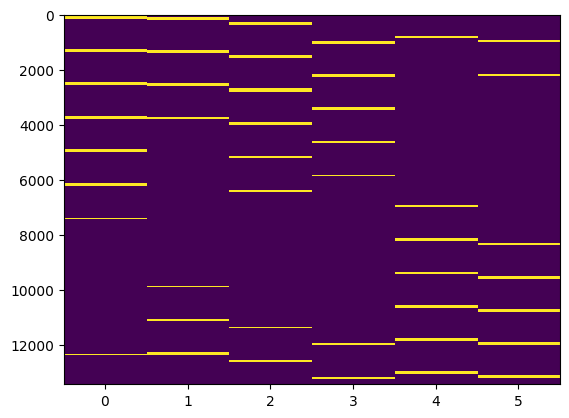

In [11]:
config_file = '/home/thomasb/albatros_analysis/scripts/orbcomm/config2_corr.json'
pulsedata_file = '/scratch/thomasb/pulsedata_1753132820_len_67200_1760916439.json'

config_data = load_json(config_file)
pulsedata_data = load_json(pulsedata_file)
get_shared_pulses(config_data, pulsedata_data)